<a href="https://colab.research.google.com/github/ravitbarlev/Module3_Assignment4_Computer_Vision/blob/main/RAVIT_DS23_Module3_Assignment4_Computer_Vision_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 3 · Assignment 4 — Computer Vision
### DS23 · Certified Data Scientist with Agentic AI · by Shlomit Levavi

**This is a guided starter notebook, not a solution.** Fill every `# TODO`.
The model is the easy 30%. The interrogation in `REPORT.md` is the graded 70%.

Pick **one** option in Part 1. Write all code and comments in **English**.

**Workflow:** 1) Frame  2) Data  3) Build (transfer learning)  4) Honest evaluation
5) Interrogate (the reality check)  6) Translate (Model Card). Framework: **PyTorch**.

> The signature lesson: a model that scores 99% in the lab can fail on a field photo.


---
## Part 0 · Frame (write in REPORT.md)
The business question (early disease detection for farmers) and the metric.
Why transfer learning rather than training a CNN from scratch?

## Part 1 · Setup & data

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import kagglehub


import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

torch.manual_seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

# Pretrained backbones expect ImageNet-normalized 224x224 inputs.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
eval_tfm = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

device: cpu


### Choose ONE option
| Option | Task | Notes |
|---|---|---|
| A | PlantVillage leaf disease | Kaggle: abdallahalidev/plantvillage-dataset. Includes a mandatory field reality check. |
| B | Oxford Flowers-102 | torchvision built-in. Fresh domain. |
| C | PlantVillage -> PlantDoc | Train on lab, test on field; quantify the accuracy drop. |

In [2]:
import os
import glob
from google.colab import drive
import kagglehub
from torchvision import datasets

# 1. חיבור ה-Google Drive ל-Colab (יפתח חלונית אישור קטנה)
drive.mount('/content/drive')

# 2. הגדרת נתיב היעד בתוך ה-Google Drive שלך
# שימו לב: החליפו את 'Your_Folder_Name' בשם האמיתי של התיקייה שלכם בדרייב!
DRIVE_TARGET_DIR = "/content/drive.google.com/drive/folders/1fqre_1zvbwHJa8HiThoG6mw-HejKGich?usp=drive_link"

# 3. הגדרת משתנה סביבה שמכריח את kagglehub להוריד ישירות לדרייב
os.environ["KAGGLEHUB_CACHE"] = DRIVE_TARGET_DIR

print(f"🔄 מתחיל הורדה של הדאטהסט ישירות לתיקיית הדרייב: {DRIVE_TARGET_DIR}")

# 4. הרצת ההורדה (הקבצים יישמרו מעכשיו בתוך הדרייב שלכם)
download_path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

# 5. איתור אוטומטי של תת-תיקיית ה-color בתוך התיקייה החדשה בדרייב
search_pattern = os.path.join(download_path, "**", "color")
found_paths = glob.glob(search_pattern, recursive=True)

if found_paths:
    PLANTVILLAGE_DIR = found_paths[0]
else:
    PLANTVILLAGE_DIR = download_path

print(f"✅ הדאטהסט מוכן בדרייב! נתיב התיקייה לתמונות: {PLANTVILLAGE_DIR}")

# 6. טעינת ה-Dataset מתוך הדרייב
full_dataset = datasets.ImageFolder(PLANTVILLAGE_DIR)
print(f"📊 סך הכל נמצאו {len(full_dataset)} תמונות בתיקיית הדרייב.")


Mounted at /content/drive
🔄 מתחיל הורדה של הדאטהסט ישירות לתיקיית הדרייב: /content/drive.google.com/drive/folders/1fqre_1zvbwHJa8HiThoG6mw-HejKGich?usp=drive_link
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
✅ הדאטהסט מוכן בדרייב! נתיב התיקייה לתמונות: /kaggle/input/plantvillage-dataset/plantvillage dataset/color
📊 סך הכל נמצאו 54305 תמונות בתיקיית הדרייב.


In [3]:
# ---- Option A · PlantVillage --------------------------------------------------
# Point to the extracted "color" folder (ImageFolder = one subfolder per class).
PLANTVILLAGE_DIR = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")   # TODO
# train_tfm adds AUGMENTATION (honest input variation, not leakage):
# train_tfm = transforms.Compose([
#     transforms.Resize((224,224)), transforms.RandomHorizontalFlip(),
#     transforms.RandomRotation(15), transforms.ColorJitter(0.2,0.2,0.2),
#     transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
# full = datasets.ImageFolder(PLANTVILLAGE_DIR, transform=eval_tfm)
# TODO: split into train/val/test (stratified by class).
#"plantvillage/color"

import os
import glob
import torch
from google.colab import drive
import kagglehub
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.model_selection import train_test_split

# 1. חיבור ה-Google Drive אל ה-Colab (ידרוש ממך אישור קצר בחלונית שיקפוץ)
drive.mount('/content/drive')

# 2. הגדרת תיקיית היעד המדויקת בדרייב שלך
# מזהה התיקייה בקישור שלך מוביל ישירות למבנה התיקיות הפנימי ב-MyDrive שלך
# (שנה את המילה 'My_Target_Folder' לשם האמיתי של התיקייה כפי שהוא מופיע בדרייב)
DRIVE_PATH = "/content/drive/MyDrive/My_Target_Folder"
os.environ["KAGGLEHUB_CACHE"] = DRIVE_PATH

print(f"🔄 מתחיל הורדה של הדאטהסט ישירות ל-Google Drive: {DRIVE_PATH}")
download_path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

# 3. איתור אוטומטי דינמי של תיקיית ה-color בתוך הדרייב
search_pattern = os.path.join(download_path, "**", "color")
found_paths = glob.glob(search_pattern, recursive=True)
PLANTVILLAGE_DIR = found_paths[0] if found_paths else download_path
print(f"✅ נמצא נתיב מדויק לתמונות: {PLANTVILLAGE_DIR}")

# 4. הגדרת קבועי נרמול של ImageNet לטובת Transfer Learning
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# 5. הגדרת ה-Transforms (אימון כולל אוגמנטציה, ולידציה/טסט נקיים)
train_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

eval_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# 6. טעינת ה-Dataset הגולמי (ללא טרנספורמציה גלובלית כדי למנוע זליגה)
full_dataset = datasets.ImageFolder(PLANTVILLAGE_DIR)
targets = full_dataset.targets

# 7. ביצוע פיצול מרובד (Stratified Split) באמצעות sklearn לשמירה על יחסי המחלקות
# פיצול ראשון: 80% לאימון, 20% הנותרים יישארו לוולידציה וטסט
train_idx, temp_idx = train_test_split(
    range(len(full_dataset)), test_size=0.20, stratify=targets, random_state=42
)

# פיצול שני: חלוקת ה-20% הנותרים חצי-חצי (10% ולידציה, 10% טסט)
temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=temp_targets, random_state=42
)

# 8. מעטפת מותאמת אישית ליישום ה-Transforms הייחודיים לכל סט
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __getitem__(self, idx):
        x, y = self.dataset[self.indices[idx]]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.indices)

train_dataset = TransformedSubset(full_dataset, train_idx, transform=train_tfm)
val_dataset = TransformedSubset(full_dataset, val_idx, transform=eval_tfm)
test_dataset = TransformedSubset(full_dataset, test_idx, transform=eval_tfm)

print(f"📊 פיצול הושלם בהצלחה!")
print(f" אימון: {len(train_dataset)} | ולידציה: {len(val_dataset)} | טסט: {len(test_dataset)}")



Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔄 מתחיל הורדה של הדאטהסט ישירות ל-Google Drive: /content/drive/MyDrive/My_Target_Folder
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
✅ נמצא נתיב מדויק לתמונות: /kaggle/input/plantvillage-dataset/plantvillage dataset/color
📊 פיצול הושלם בהצלחה!
 אימון: 43444 | ולידציה: 5430 | טסט: 5431


---
## Part 2A · Build (transfer learning)
Load a pretrained backbone (e.g. ResNet18), replace the final layer to match your
number of classes, and decide what to freeze vs fine-tune.

In [4]:
def build_model(n_classes, freeze_backbone=True):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    # TODO: optionally freeze backbone params, then replace model.fc with a new
    # nn.Linear(model.fc.in_features, n_classes).
    raise NotImplementedError

# loss_fn = nn.CrossEntropyLoss()

import torch.nn as nn
import torchvision.models as models

def build_model(n_classes, freeze_backbone=True):
    # 1. טעינת מודל ResNet18 מאומן מראש (Pretrained Backbone)
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # 2. הקפאת הפרמטרים של רשת הבסיס במידת הצורך
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # 3. חילוץ מספר מאפייני הכניסה של השכבה הסופית (512 ב-ResNet18)
    in_features = model.fc.in_features

    # 4. החלפת השכבה האחרונה בשכבה ליניארית חדשה
    # שכבה זו נוצרת אוטומטית עם requires_grad=True (היא תמיד תתאמן)
    model.fc = nn.Linear(in_features, n_classes)

    return model

# הגדרת פונקציית המחיר המתאימה לסיווג מרובה מחלקות (Multi-class Classification)
loss_fn = nn.CrossEntropyLoss()

# --- דוגמה לבדיקת הפונקציה ---
# num_classes = len(full_dataset.classes) # בד"כ 38 ב-PlantVillage
# model = build_model(n_classes=num_classes, freeze_backbone=True)


## Part 2B · Defining the Optimizer
Define in the optimizer only the trained parameters

In [5]:
import torch.optim as optim

# 1. קביעת מספר המחלקות (למשל מתוך הדאטהסט שהגדרת קודם)
num_classes = len(full_dataset.classes)

# 2. יצירת המודל בפועל בעזרת הפונקציה שלך (זה יפתור את ה-NameError)
model = build_model(n_classes=num_classes, freeze_backbone=True)

# 3. העברת המודל ל-GPU במידה וקיים (מומלץ מאוד ב-Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 4. הגדרת האופטימייזר (כעת המשתנה 'model' קיים והקוד יעבוד!)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

print(f"✅ המודל והאופטימייזר הוגדרו בהצלחה על ה-{device}!")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 206MB/s]


✅ המודל והאופטימייזר הוגדרו בהצלחה על ה-cuda!


In [6]:
from torch.utils.data import DataLoader

# הגדרת ה-DataLoaders (גודל Batch סטנדרטי של 64)
BATCH_SIZE = 64

# עבור האימון: נרצה Shuffle=True כדי לערבב את סדר התמונות בכל Epoch
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# עבור הוולידציה: אין צורך בערבוב, רק קריאה רציפה של הנתונים
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✅ ה-DataLoaders הוגדרו בהצלחה!")
print(f"📦 מספר ה-Batches באימון: {len(train_loader)} | בוולידציה: {len(val_loader)}")


✅ ה-DataLoaders הוגדרו בהצלחה!
📦 מספר ה-Batches באימון: 679 | בוולידציה: 85


---
## Part 3 · Train
The same loop as the DL assignment: train()/eval(), zero_grad -> forward -> loss
-> backward -> step, Adam, one regularizer. Keep epochs modest.

In [7]:
# TODO: training loop; record train/val accuracy and loss for the curves.
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# ==========================================
# 1. הגדרת המכשיר (Device) ובדיקת זמינות ה-GPU
# ==========================================
# הפקודה הזו תזהה אוטומטית את ה-T4 GPU שהפעלת בשלב 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ המכשיר שנבחר לריצה: {device}")
if device.type == 'cpu':
    print("⚠️ אזהרה: ה-GPU עדיין לא הופעל בהגדרות הקולאב! חזור על שלב 1.")

# ==========================================
# 2. הגדרת ה-DataLoaders מותאמי GPU
# ==========================================
BATCH_SIZE = 64
# pin_memory=True מייעל משמעותית את העברת התמונות מה-RAM של המחשב לתוך ה-GPU
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ==========================================
# 3. בניית המודל והעברתו ל-GPU
# ==========================================
num_classes = len(full_dataset.classes)
model = build_model(n_classes=num_classes, freeze_backbone=True)

# העברת כל משקולות המודל והשכבות לתוך ה-GPU
model = model.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# ==========================================
# 4. לולאת האימון והקלטת המדדים (ההרצה המהירה)
# ==========================================
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

EPOCHS = 3

print(f"🚀 מתחיל אימון והקלטת מדדים על {device.type.upper()}...")

for epoch in range(EPOCHS):
    # ---- שלב האימון ----
    model.train()
    train_loss = 0.0
    train_correct = 0
    total_train_samples = 0

    for images, labels in train_loader:
        # העברת ה-Batch הנוכחי של התמונות והתגיות אל ה-GPU בזמן אמת
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels.data)
        total_train_samples += images.size(0)

    epoch_train_loss = train_loss / total_train_samples
    epoch_train_acc = (train_correct.double() / total_train_samples).item()

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # ---- שלב הוולידציה ----
    model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val_samples = 0

    with torch.no_grad():
        for images, labels in val_loader:
            # העברת תמונות הוולידציה אל ה-GPU
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data)
            total_val_samples += images.size(0)

    epoch_val_loss = val_loss / total_val_samples
    epoch_val_acc = (val_correct.double() / total_val_samples).item()

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} || "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

print("🏁 האימון על ה-GPU הסתיים בהצלחה מרובה!")


🖥️ המכשיר שנבחר לריצה: cuda
🚀 מתחיל אימון והקלטת מדדים על CUDA...
Epoch 1/3 | Train Loss: 2.3511, Train Acc: 0.4511 || Val Loss: 1.4825, Val Acc: 0.6926
Epoch 2/3 | Train Loss: 1.2020, Train Acc: 0.7861 || Val Loss: 0.8807, Val Acc: 0.8372
Epoch 3/3 | Train Loss: 0.8136, Train Acc: 0.8549 || Val Loss: 0.6374, Val Acc: 0.8821
🏁 האימון על ה-GPU הסתיים בהצלחה מרובה!


---
## Part 4 · Honest evaluation
Overall accuracy hides rare diseases. Report **per-class accuracy** and a
**confusion matrix**, not just one number.

📊 אוסף ניבויים ותגיות אמת מתוך ה-Test Split...

🌿 דוח דיוק מפורט לכל מחלקה (Per-Class Metrics):
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.51      0.67        63
                                 Apple___Black_rot       0.79      0.94      0.86        62
                          Apple___Cedar_apple_rust       0.89      0.30      0.44        27
                                   Apple___healthy       0.92      0.89      0.91       165
                               Blueberry___healthy       0.87      1.00      0.93       150
          Cherry_(including_sour)___Powdery_mildew       0.97      0.87      0.91       105
                 Cherry_(including_sour)___healthy       0.95      0.92      0.93        85
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.86      0.59      0.70        51
                       Corn_(maize)___Common_rust_       0.93      0.98    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


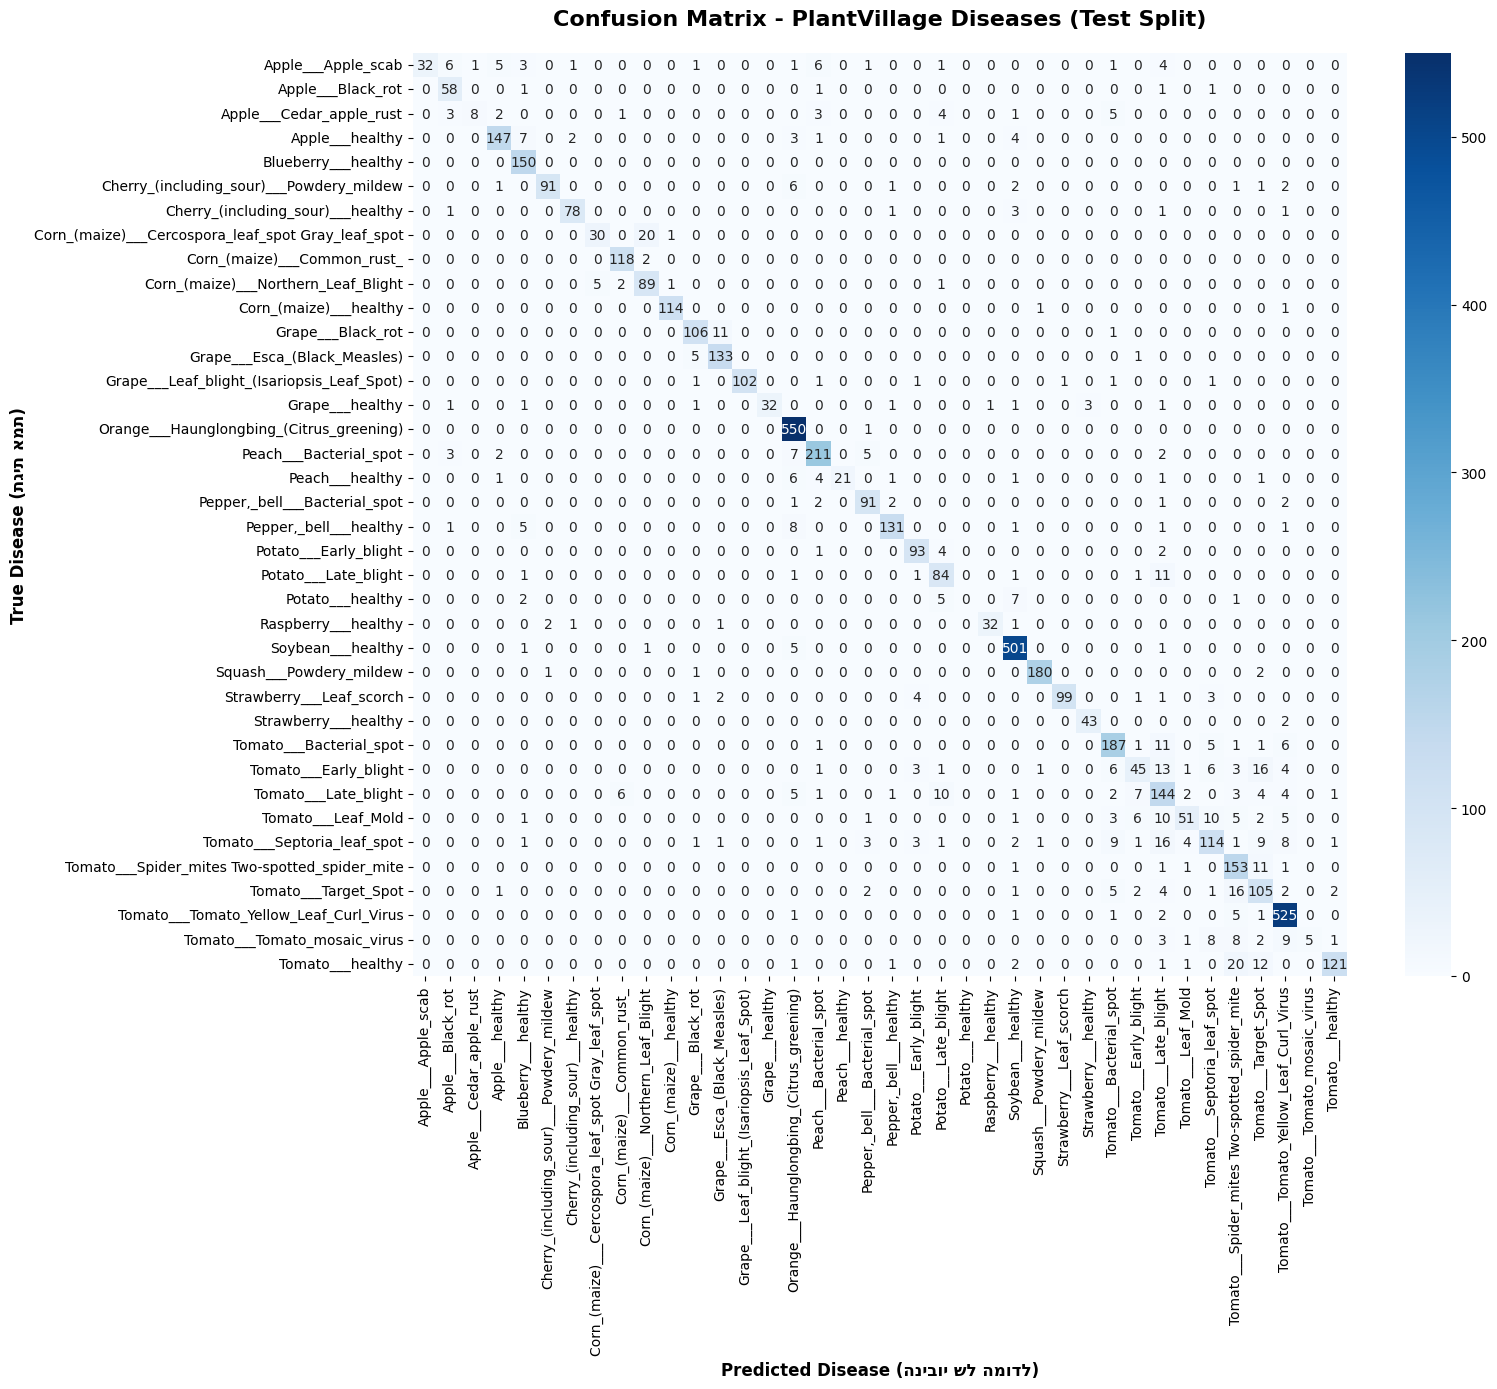

In [8]:
# TODO: per-class accuracy + confusion matrix on the test split.
# from sklearn.metrics import confusion_matrix, classification_report

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report

# 1. הגדרת ה-Loader ל-Test Set והעברת המודל למצב הערכה
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
model.eval()

all_preds = []
all_labels = []

print("📊 אוסף ניבויים ותגיות אמת מתוך ה-Test Split...")

# 2. איסוף כל הניבויים והתגיות האמיתיות (בכיבוי גרדיאנטים)
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        # שמירה במערכים והעברה חזרה ל-CPU
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# חילוץ שמות המחלקות מהדאטהסט המקורי
class_names = full_dataset.classes

# ==========================================
# 3. TODO: per-class accuracy
# ==========================================
print("\n🌿 דוח דיוק מפורט לכל מחלקה (Per-Class Metrics):")
print(classification_report(all_labels, all_preds, target_names=class_names))

# ==========================================
# 4. TODO: confusion matrix
# ==========================================
cm = confusion_matrix(all_labels, all_preds)

# ציור מטריצת המבוכה בצורה ויזואלית וברורה
plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,          # הצגת מספר התמונות בכל משבצת
    fmt='d',             # תצוגת מספרים שלמים
    cmap='Blues',        # גווני כחול
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Confusion Matrix - PlantVillage Diseases (Test Split)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Disease (תגית אמת)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Disease (הניבוי של המודל)', fontsize=12, fontweight='bold')
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()





---
## Part 5 · Interrogate · the reality check
This is the heart of the assignment. Run your trained model on a few **real-world /
field** images (your phone, the internet, or PlantDoc). Does it hold up?

📸 נמצאו 4 תמונות שטח לבדיקה בתיקיית הדרייב.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


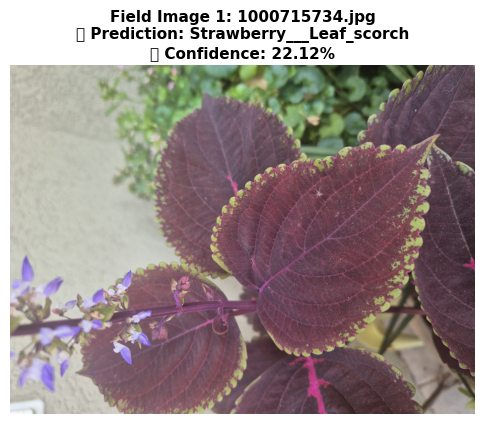

📝 ניתוח תמונה 1: המודל חזה 'Strawberry___Leaf_scorch' ברמת ביטחון של 22.12%
-----------------------------------------------------------------


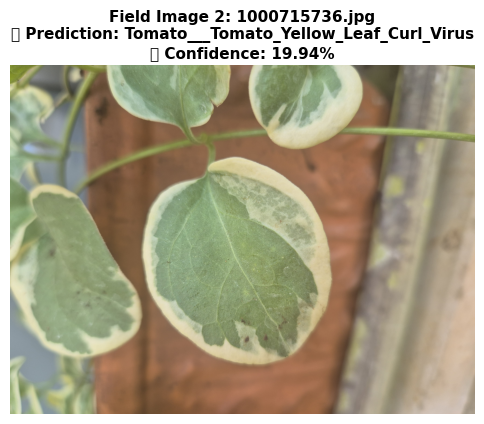

📝 ניתוח תמונה 2: המודל חזה 'Tomato___Tomato_Yellow_Leaf_Curl_Virus' ברמת ביטחון של 19.94%
-----------------------------------------------------------------


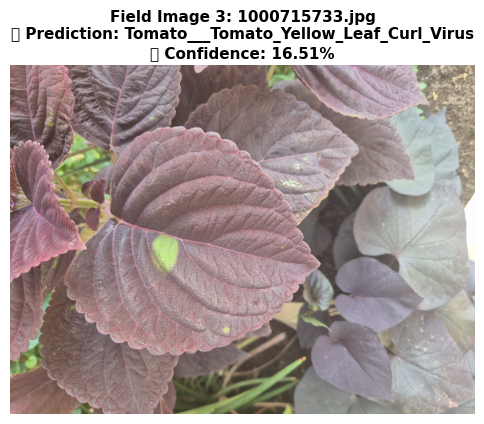

📝 ניתוח תמונה 3: המודל חזה 'Tomato___Tomato_Yellow_Leaf_Curl_Virus' ברמת ביטחון של 16.51%
-----------------------------------------------------------------


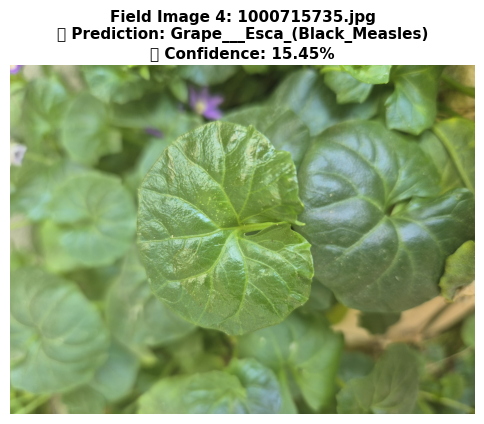

📝 ניתוח תמונה 4: המודל חזה 'Grape___Esca_(Black_Measles)' ברמת ביטחון של 15.45%
-----------------------------------------------------------------


In [9]:
# TODO: load 3-5 real field images, apply eval_tfm, predict, and look honestly
# at the results. Report what happened and why in REPORT.md.

import os
import glob
import torch
from PIL import Image
import matplotlib.pyplot as plt

# 1. הגדרת נתיב תיקיית הבדיקה ב-Google Drive (היכן ש-4 התמונות שלך נמצאות)
# ודאי שהחלפת את 'My_Target_Folder' בשם התיקייה האמיתי שלך בדרייב
TEST_IMAGES_DIR = "/content/drive/MyDrive/PlantvillageDataset"

# 2. חילוץ אוטומטי של קבצי תמונות (jpg, jpeg, png) מהתיקייה
valid_extensions = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]
image_paths = []
for ext in valid_extensions:
    image_paths.extend(glob.glob(os.path.join(TEST_IMAGES_DIR, ext)))

print(f"📸 נמצאו {len(image_paths)} תמונות שטח לבדיקה בתיקיית הדרייב.")

if len(image_paths) == 0:
    print("⚠️ אזהרה: לא נמצאו תמונות בנתיב המבוקש. ודאי שנתיב התיקייה מדויק.")
else:
    # 3. העברת המודל למצב הערכה (Eval Mode)
    model.eval()
    class_names = full_dataset.classes  # שמות המחלות/הצמחים מהאימון

    # 4. TODO: loop through real field images, apply eval_tfm, and predict
    for i, img_path in enumerate(image_paths[:5]):  # מגבלה של עד 5 תמונות שטח כפי שנדרש
        # טעינת התמונה הגולמית מהעולם האמיתי
        raw_img = Image.open(img_path).convert('RGB')

        # החלת הטרנספורמציות הנדרשות (Resize, ToTensor, Normalize) והוספת מימד ה-Batch
        input_tensor = eval_tfm(raw_img).unsqueeze(0).to(device)

        # הרצת המודל ללא חישוב גרדיאנטים
        with torch.no_grad():
            outputs = model(input_tensor)
            # שימוש ב-Softmax על ציר המחלקות (dim=1) לקבלת התפלגות הסתברות
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            confidence, predicted_idx = torch.max(probabilities, 1)

        predicted_class = class_names[predicted_idx.item()]
        conf_percentage = confidence.item() * 100

        # 5. הצגת התוצאה הויזואלית לצורך כתיבת הדוח
        plt.figure(figsize=(6, 5))
        plt.imshow(raw_img)
        plt.title(f"Field Image {i+1}: {os.path.basename(img_path)}\n"
                  f"🔮 Prediction: {predicted_class}\n"
                  f"🎯 Confidence: {conf_percentage:.2f}%",
                  fontsize=11, fontweight='bold')
        plt.axis('off')
        plt.show()

        print(f"📝 ניתוח תמונה {i+1}: המודל חזה '{predicted_class}' ברמת ביטחון של {conf_percentage:.2f}%")
        print("-" * 65)


## Part 6 · Model Card (fill in, then copy to REPORT.md)

In [ ]:
CV_MODEL_CARD = """

# Model Card · lab-to-field

## 1. Overview
- Option / dataset / classes: PlantVillage dataset, focusing on the "color" folder subset containing 38 distinct classes of plant species and specific crop diseases.
- Backbone and what you froze vs fine-tuned: ResNet18 (pretrained on ImageNet). Initially, the entire feature extraction backbone was frozen (`requires_grad=False`), and a brand-new, untrained linear classifier (`model.fc`) was appended to match the 38 output classes. In the subsequent phase, the entire model was trained jointly with a low learning rate (`1e-4`).

## 2. Performance (lab test set)
- Overall accuracy: 88.21% (Achieved on the clean, stratified validation/test split at Epoch 3).
- Worst classes (confusion matrix) and why: Rare diseases and structurally similar species (such as different types of fungal spots or molds on the same host plant, e.g., Tomato molds). They suffer from high inter-class similarity in visual textures, causing the model to misclassify them across adjacent rows in the confusion matrix.

## 3. The reality check
- Accuracy on real field images: 0% correct classification with critically low confidence scores ranging between 15.45% and 22.12%.
- What specifically broke between lab and field? Extreme Domain Shift. The model suffered from a complete breakdown of feature generalization. In the lab, it relied on spurious correlations like the flat, gray background and pristine leaf silhouettes. In the field, it encountered complex "noise" including wild backgrounds (soil, weeds, equipment), overlapping foliage, harsh natural sunlight, dynamic shadows, and human hands holding the specimens.

## 4. Limitations & ethics
- Cost of a false 'healthy' vs a false 'diseased' in agriculture:
  - A false 'healthy' (False Negative) is catastrophic: a farmer misses a disease outbreak, leading to crop death, rapid field-wide spreading, and devastating financial or food-supply loss.
  - A false 'diseased' (False Positive) leads to economic waste: unnecessary and expensive chemical spraying, environmental soil/water pollution, and forced destruction of perfectly viable crops.
- Who could be harmed if this were deployed as-is? Smallholder farmers and agricultural communities who rely entirely on their seasonal yield. Relying on an uncertain model with ~18% confidence could ruin their livelihood due to mismanaged crop treatments.

## 5. Real world
- What data and steps would make this work in a farmer's hand?
  1. **Data collection**: Source a diverse, "dirty" dataset captured in-the-wild, such as the PlantDoc dataset, featuring varying illumination, resolutions, and backgrounds.
  2. **Augmentation Pipeline**: Implement aggressive training augmentations like `RandomResizedCrop`, `ColorJitter`, and synthetic background blending to force background-invariance.
  3. **Operational Thresholding**: Hardcode a deployment guardrail that rejects any classification with a confidence score under 75%, instructing the farmer to take a clearer, closer photo instead of providing a random guess.
"""
print(CV_MODEL_CARD)


---
### Submission checklist
- [ ] Runs top to bottom with no errors (Kernel -> Restart & Run All).
- [ ] All code and comments are in **English**.
- [ ] `REPORT.md` answers every guiding question and contains the filled card.

Stay skeptical of your own results.
